# Análisis Univariado del Dataset Stablecoins

In [28]:
# Se importan las librerías necesarias para el análisis de datos y visualización
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [21]:
# se cargan los datos de stablecoins desde un archivo CSV
df = pd.read_csv("../data/stablecoins.csv")

In [24]:
# se observan las primeras filas del DataFrame para entender su estructura y contenido
df.head()

,price,market_cap,datetime,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,stablecoin,stablecoin_id
0,1.002412,110105.0,2017-12-06,0.002412,0.0,0.0,0.001469,USDT,1
1,1.001515,110105.0,2017-12-07,0.001515,0.0,0.0,0.000907,USDT,1
2,0.999473,110105.0,2017-12-08,0.000527,0.0,0.0,0.001506,USDT,1
3,0.999584,110105.0,2017-12-09,0.000416,0.0,0.0,0.001148,USDT,1
4,1.000546,110105.0,2017-12-10,0.000546,0.0,0.0,0.000590,USDT,1


In [25]:
# información general del DataFrame, incluyendo el número de entradas, columnas, tipos de datos y memoria utilizada
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21575 entries, 0 to 21574
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                21575 non-null  float64
 1   market_cap           21575 non-null  float64
 2   datetime             21575 non-null  str    
 3   peg_deviation        21575 non-null  float64
 4   supply_change_1d     21575 non-null  float64
 5   supply_change_7d     21575 non-null  float64
 6   price_volatility_3d  21575 non-null  float64
 7   stablecoin           21575 non-null  str    
 8   stablecoin_id        21575 non-null  int64  
dtypes: float64(6), int64(1), str(2)
memory usage: 1.8 MB


In [26]:
# Dimensiones del DataFrame, es decir, el número de filas y columnas
df.shape

(21575, 9)

In [29]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,21575.0,9.999600e-01,1.892688e-03,9.420000e-01,9.991939e-01,9.999979e-01,1.000808e+00,1.005042e+00
market_cap,21575.0,1.546335e+10,3.468685e+10,1.101050e+05,1.322493e+08,6.929045e+08,6.569135e+09,1.902405e+11
peg_deviation,21575.0,1.004683e-03,1.604504e-03,2.155425e-07,3.848583e-04,8.073728e-04,1.388404e-03,5.800000e-02
supply_change_1d,21575.0,1.516249e-02,1.859014e+00,-8.615129e-01,-2.293128e-03,8.738229e-05,3.631028e-03,2.728006e+02
supply_change_7d,21575.0,1.053735e-01,4.916832e+00,-8.719827e-01,-1.004525e-02,9.861619e-04,1.954086e-02,2.728006e+02
price_volatility_3d,21575.0,1.139032e-03,1.514133e-03,8.651009e-06,6.389432e-04,1.003046e-03,1.432185e-03,3.477824e-02
stablecoin_id,21575.0,5.267856e+00,2.931759e+00,1.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01


In [27]:
# Valores nulos por columna, para identificar si hay datos faltantes que puedan afectar el análisis
df.isnull().sum()

price                  0
market_cap             0
datetime               0
peg_deviation          0
supply_change_1d       0
supply_change_7d       0
price_volatility_3d    0
stablecoin             0
stablecoin_id          0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df["stablecoin"].value_counts()

stablecoin
USDT     3133
USDC     2831
USDD     2731
FDUSD    2413
BUSD     2257
TUSD     2011
PYUSD    1912
FRAX     1910
USDE     1852
DAI       525
Name: count, dtype: int64

Interpretación:

El conjunto de datos contiene información histórica de varias stablecoins. Cada registro incluye el precio, la capitalización de mercado, la desviación respecto a la paridad con el dólar (peg deviation), cambios en la oferta y volatilidad del precio, lo que permitirá analizar el comportamiento individual de cada activo.

In [32]:
# Convertir fecha a tipo datetime para facilitar el análisis temporal
df["datetime"] = pd.to_datetime(df["datetime"])

In [36]:
# Función para histogramas

import math
import matplotlib.pyplot as plt
import seaborn as sns

def histograma_por_stablecoin(df, variable, titulo, xlabel, bins=30):

    monedas = sorted(df["stablecoin"].unique())

    n = len(monedas)
    ncols = 3                      # 3 gráficos por fila
    nrows = math.ceil(n / ncols)

    colores = sns.color_palette("tab20", n)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(18, 5*nrows)
    )

    axes = axes.flatten()

    for ax, moneda, color in zip(axes, monedas, colores):

        datos = df[df["stablecoin"] == moneda]

        sns.histplot(
            data=datos,
            x=variable,
            bins=bins,
            kde=True,
            color=color,
            edgecolor="black",
            alpha=0.8,
            ax=ax
        )

        ax.set_title(moneda, fontsize=12, fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecuencia")
        ax.grid(alpha=0.3)

    # Ocultar ejes vacíos
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle(titulo, fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Variable: Stablecoin

Tipo

Variable categórica.

Contiene 10 stablecoins diferentes.

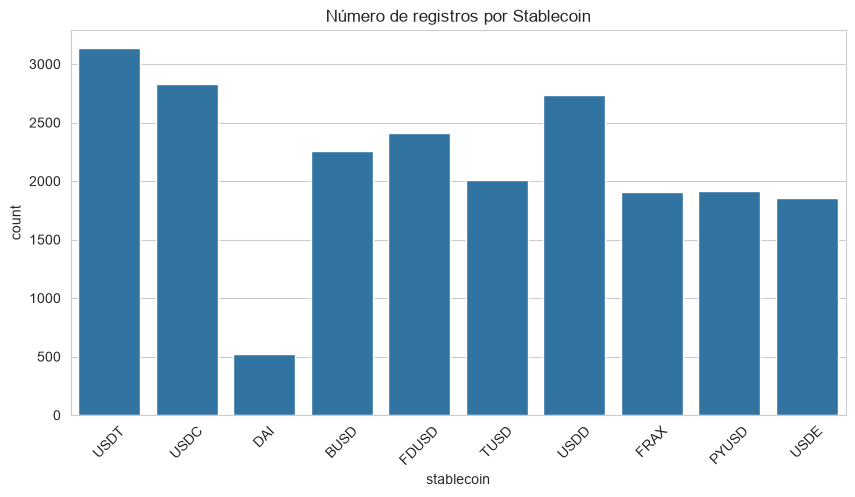

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="stablecoin")
plt.xticks(rotation=45)
plt.title("Número de registros por Stablecoin")
plt.show()

Interpretación

El conjunto de datos incluye información histórica de diez stablecoins diferentes. La distribución de registros es bastante equilibrada, aunque algunas monedas disponen de un mayor historial temporal que otras. Esto permite realizar comparaciones entre activos sin un sesgo importante.

# Variable Price

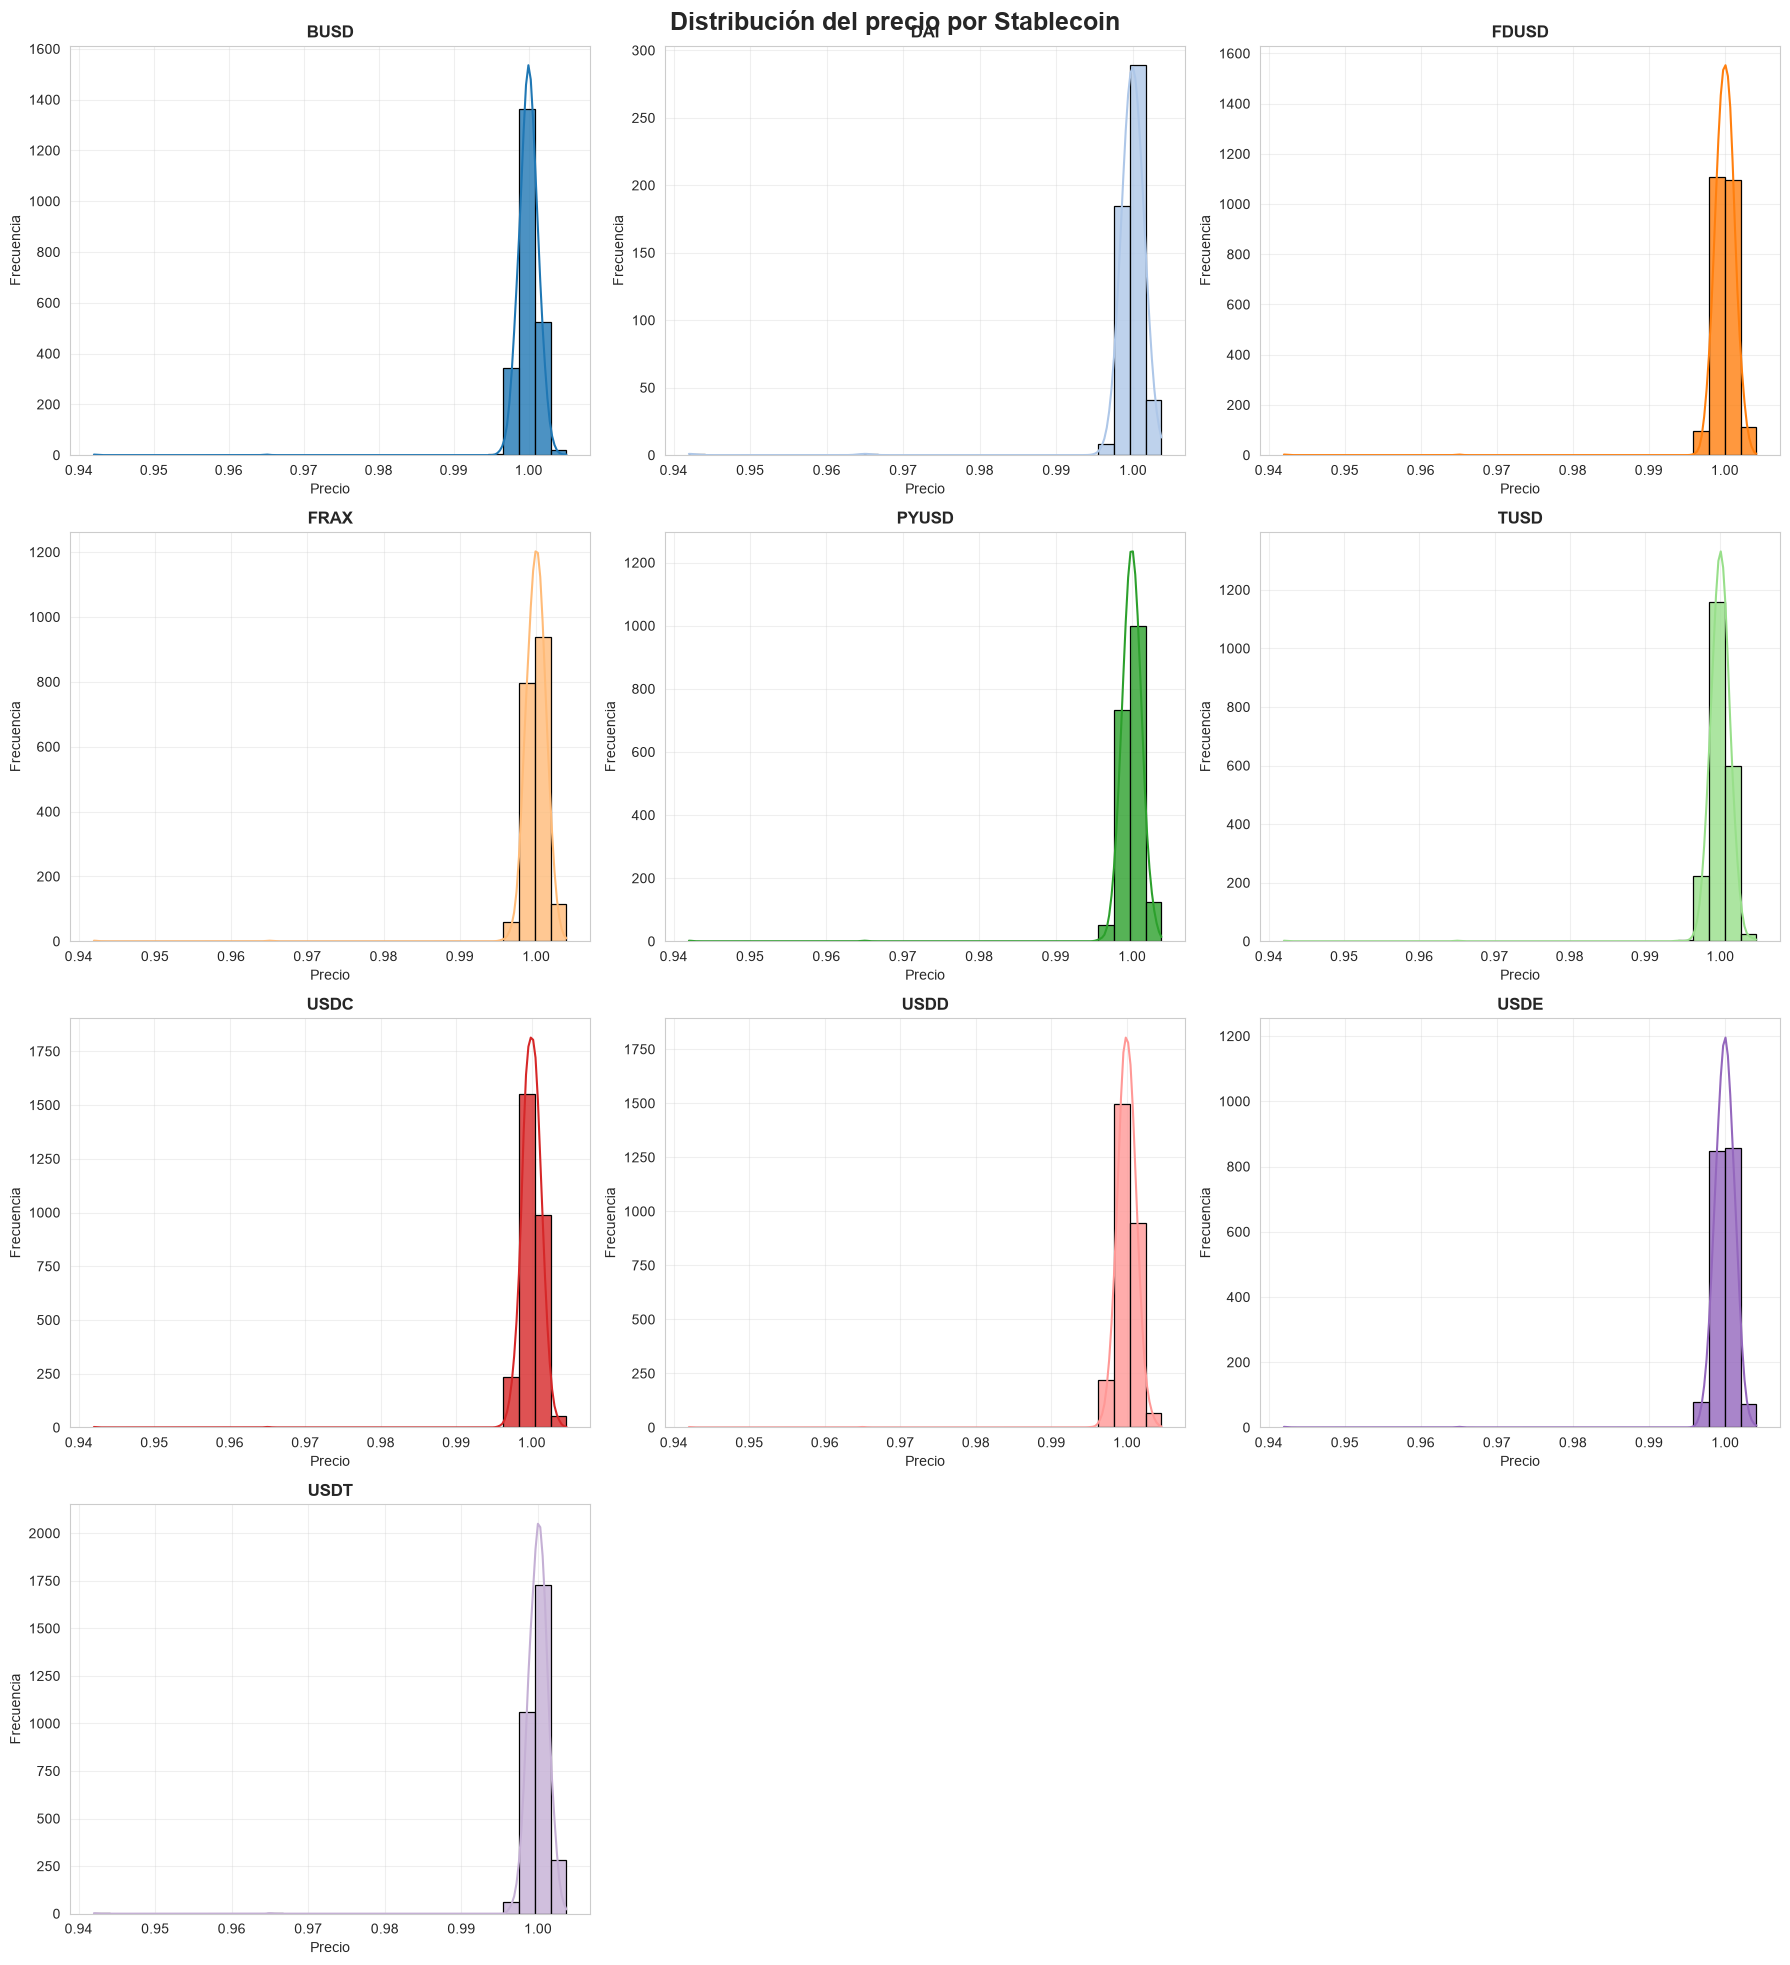

In [37]:
histograma_por_stablecoin(
    df,
    "price",
    "Distribución del precio por Stablecoin",
    "Precio"
)

Interpretación

La mayor parte de las observaciones se concentran alrededor del valor de 1 dólar, comportamiento esperado en una stablecoin. Sin embargo, existen algunas desviaciones importantes, alcanzando mínimos cercanos a 0.94 USD, lo que evidencia episodios de pérdida temporal del peg (depeg).

# Variable Market Cap

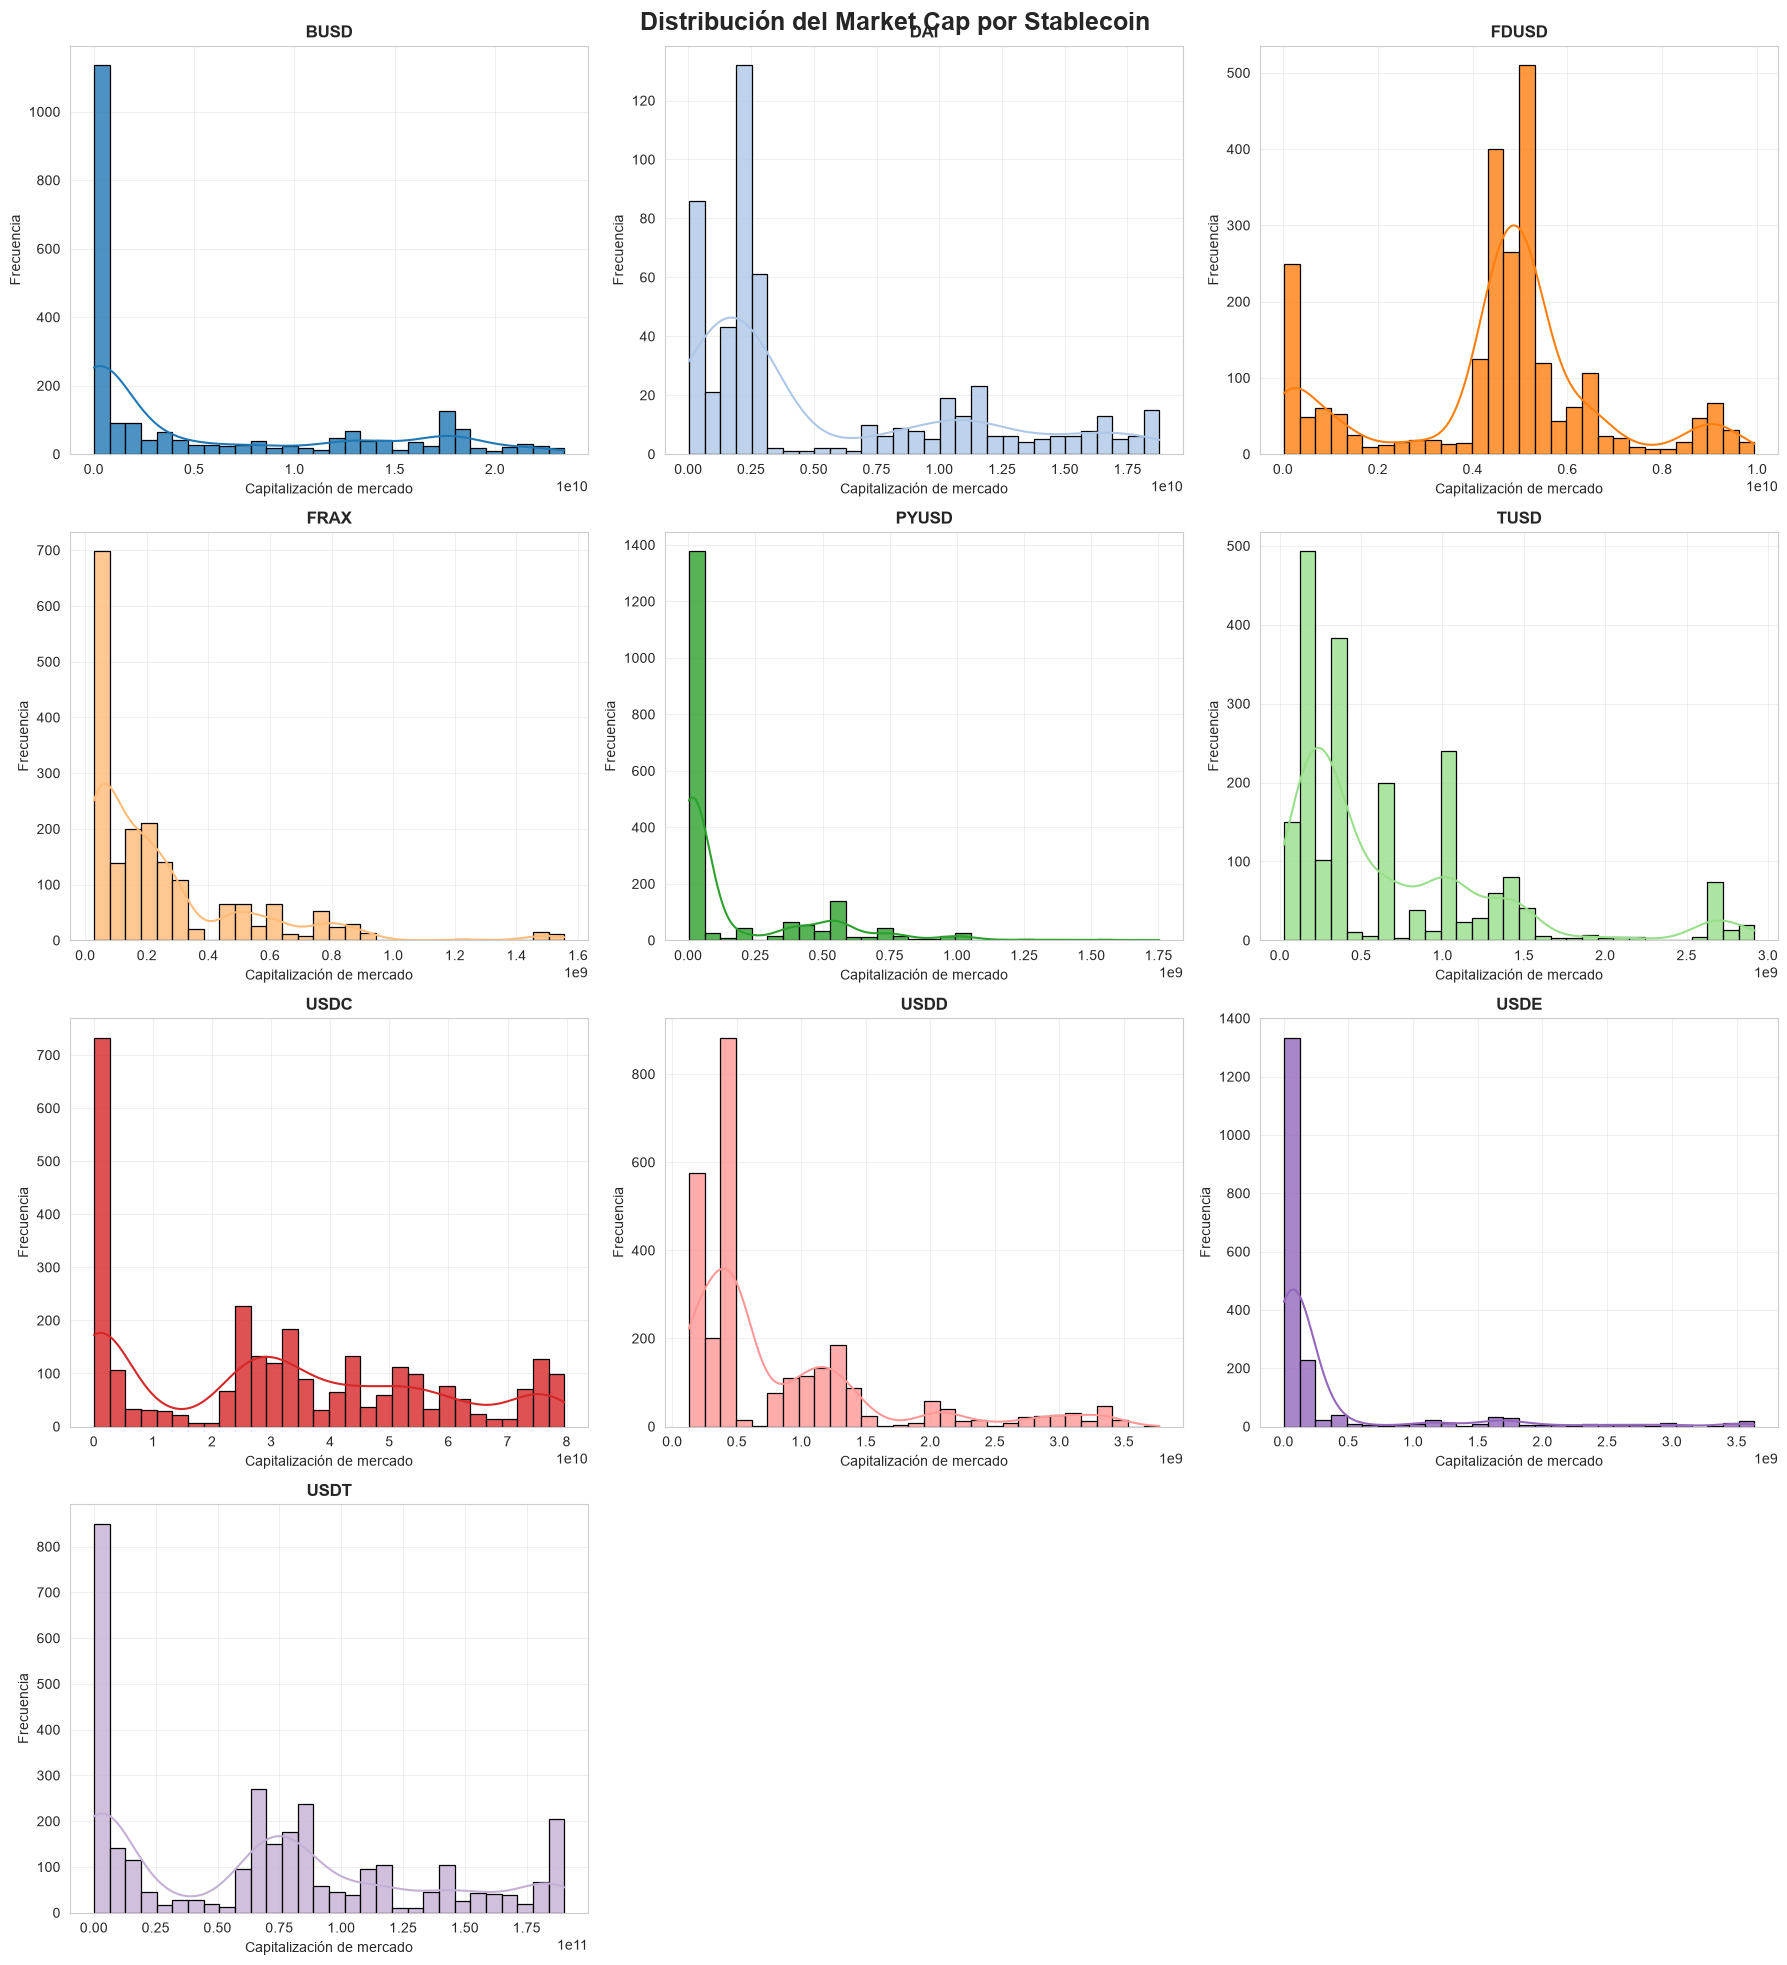

In [38]:
histograma_por_stablecoin(
    df,
    "market_cap",
    "Distribución del Market Cap por Stablecoin",
    "Capitalización de mercado"
)

Interpretación

La distribución presenta una fuerte asimetría positiva. La mayoría de las stablecoins poseen una capitalización relativamente baja, mientras que unas pocas, como USDT o USDC, concentran gran parte del mercado. Los valores extremos son esperables y representan diferencias reales en el tamaño de estos activos.

# Variable Peg Deviation

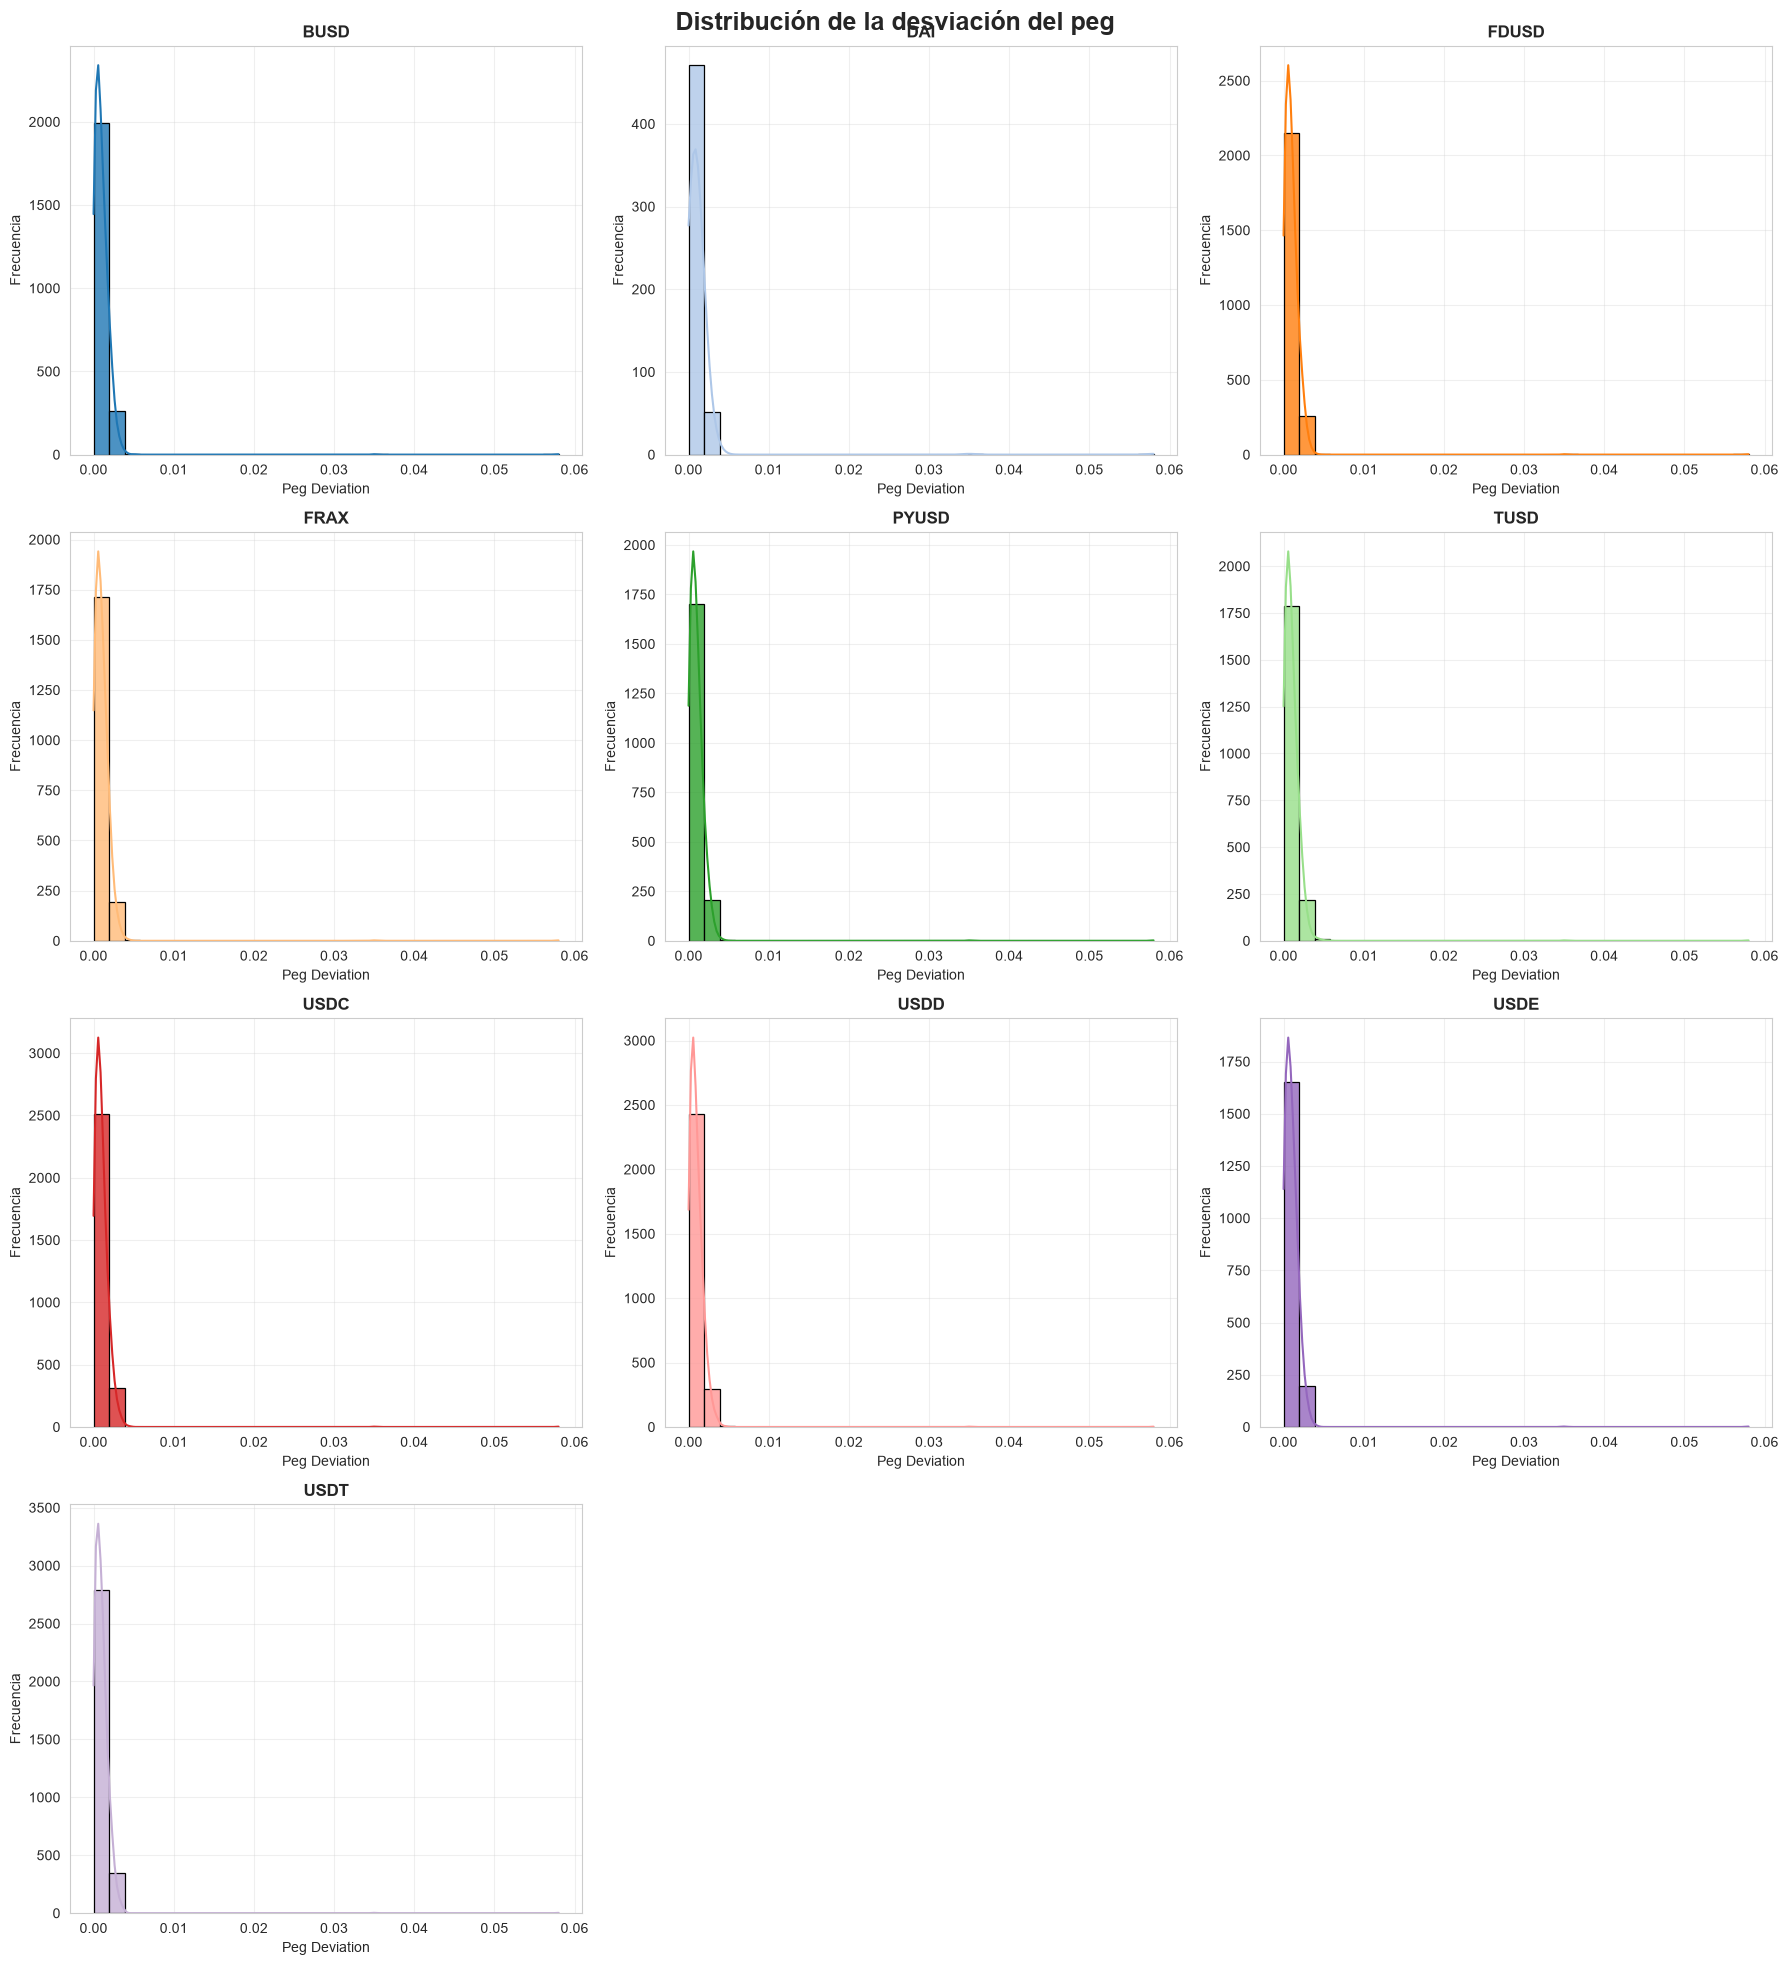

In [40]:
histograma_por_stablecoin(
    df,
    "peg_deviation",
    "Distribución de la desviación del peg",
    "Peg Deviation"
)

Interpretación

La mayoría de los registros muestran desviaciones muy pequeñas respecto al peg, lo que indica un funcionamiento estable del mercado. Sin embargo, aparecen algunos valores extremos que representan episodios de pérdida temporal de estabilidad, aspecto fundamental dentro de este proyecto.

# Variable: Supply Change 1D

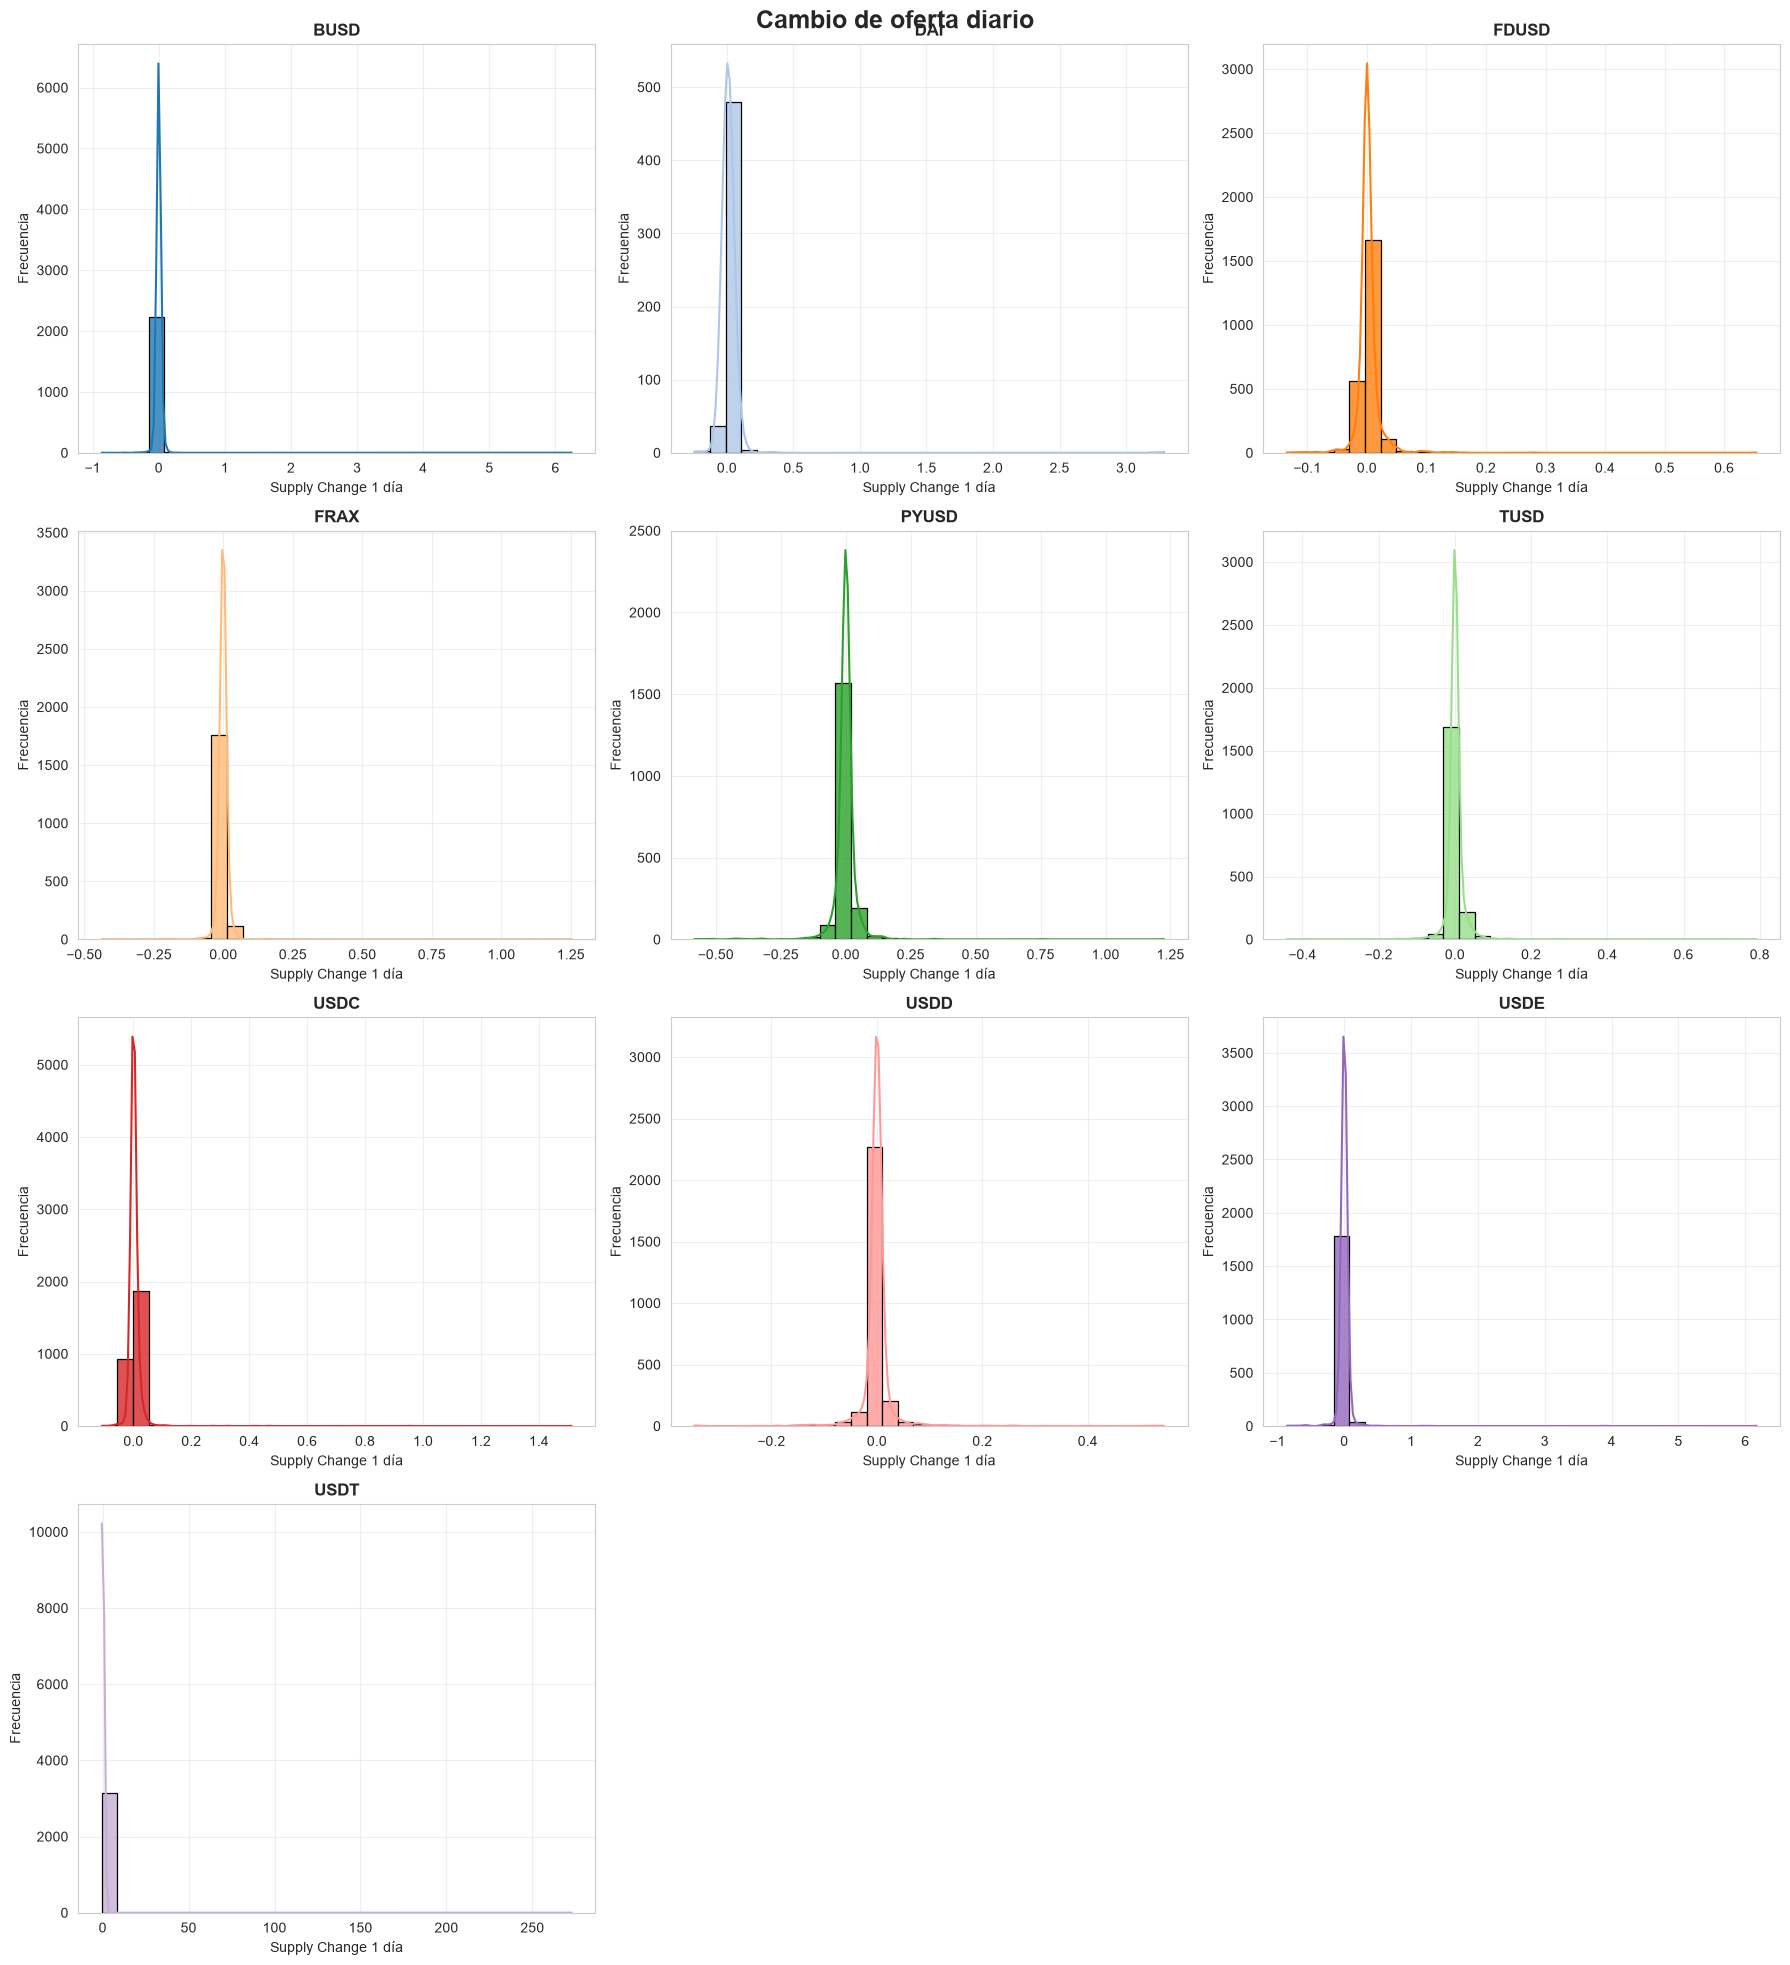

In [41]:
histograma_por_stablecoin(
    df,
    "supply_change_1d",
    "Cambio de oferta diario",
    "Supply Change 1 día"
)

Interpretación

La mayoría de los cambios diarios son pequeños, aunque existen incrementos extraordinarios que pueden corresponder a emisiones masivas o eventos excepcionales. La distribución presenta una fuerte asimetría positiva y numerosos valores atípicos.

# Variable: Supply Change 7D

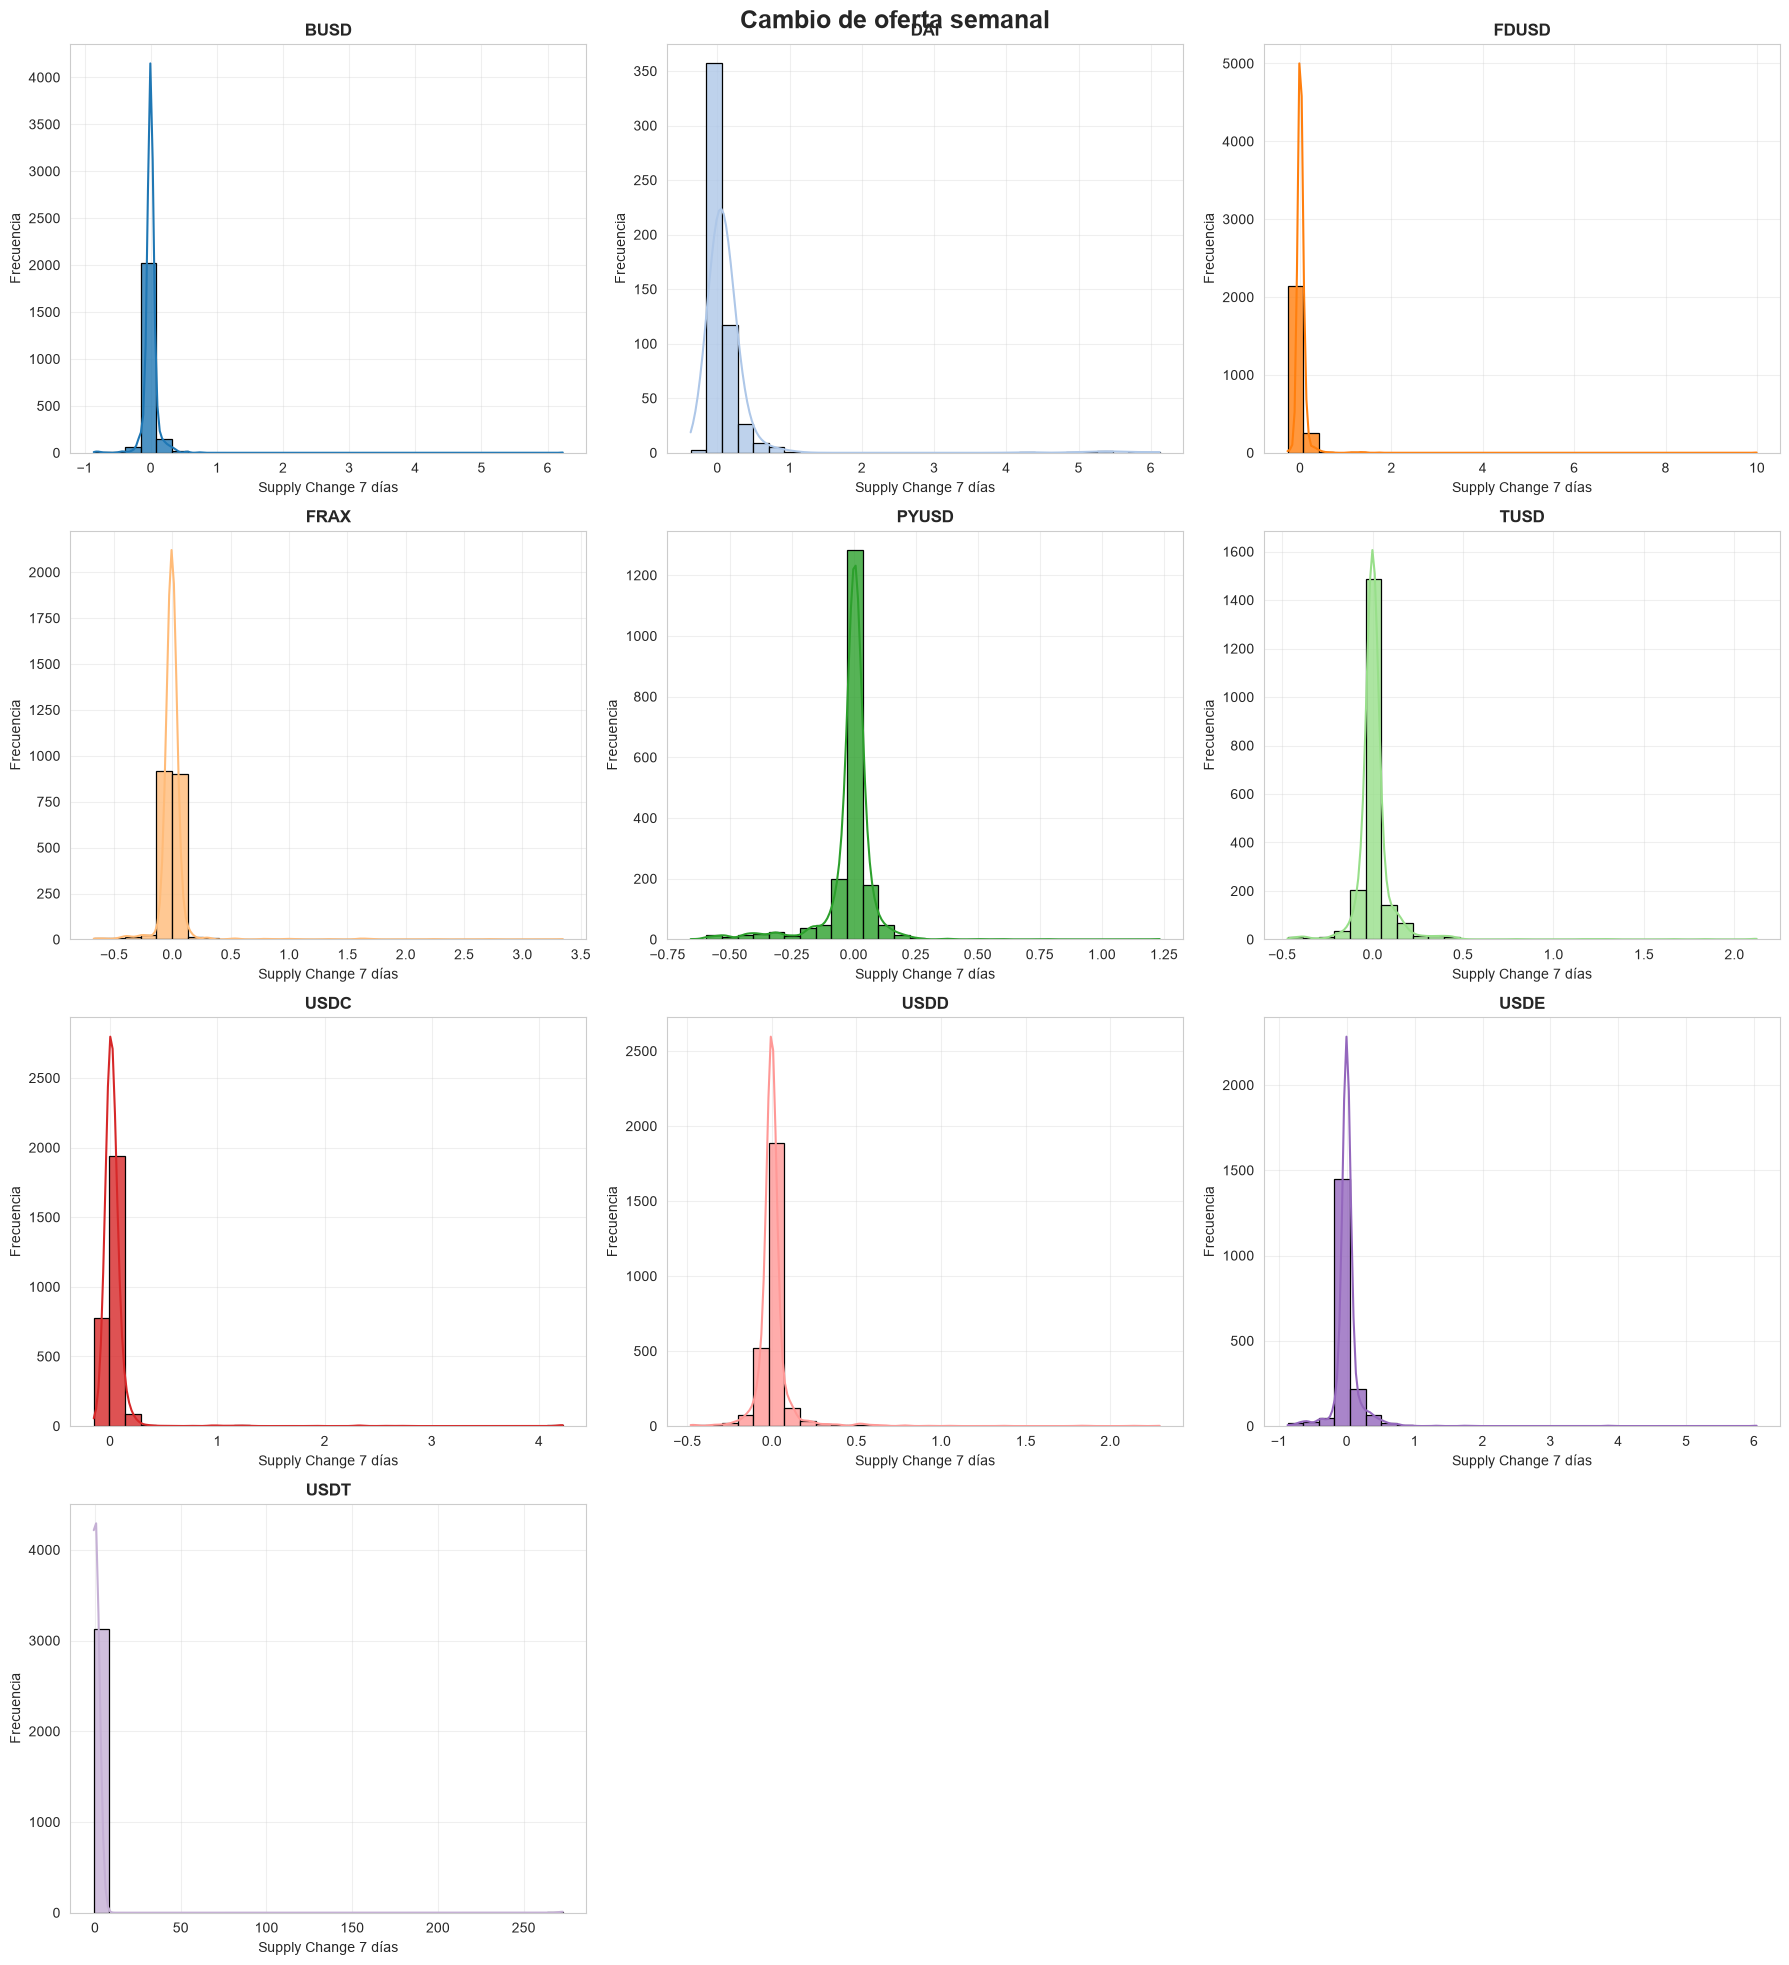

In [42]:
histograma_por_stablecoin(
    df,
    "supply_change_7d",
    "Cambio de oferta semanal",
    "Supply Change 7 días"
)

Interpretación

El comportamiento es similar al observado en el cambio diario, aunque con una mayor dispersión. Las variaciones semanales permiten identificar tendencias de crecimiento o reducción sostenida en la emisión de stablecoins.

# Variable: Price Volatility 3D

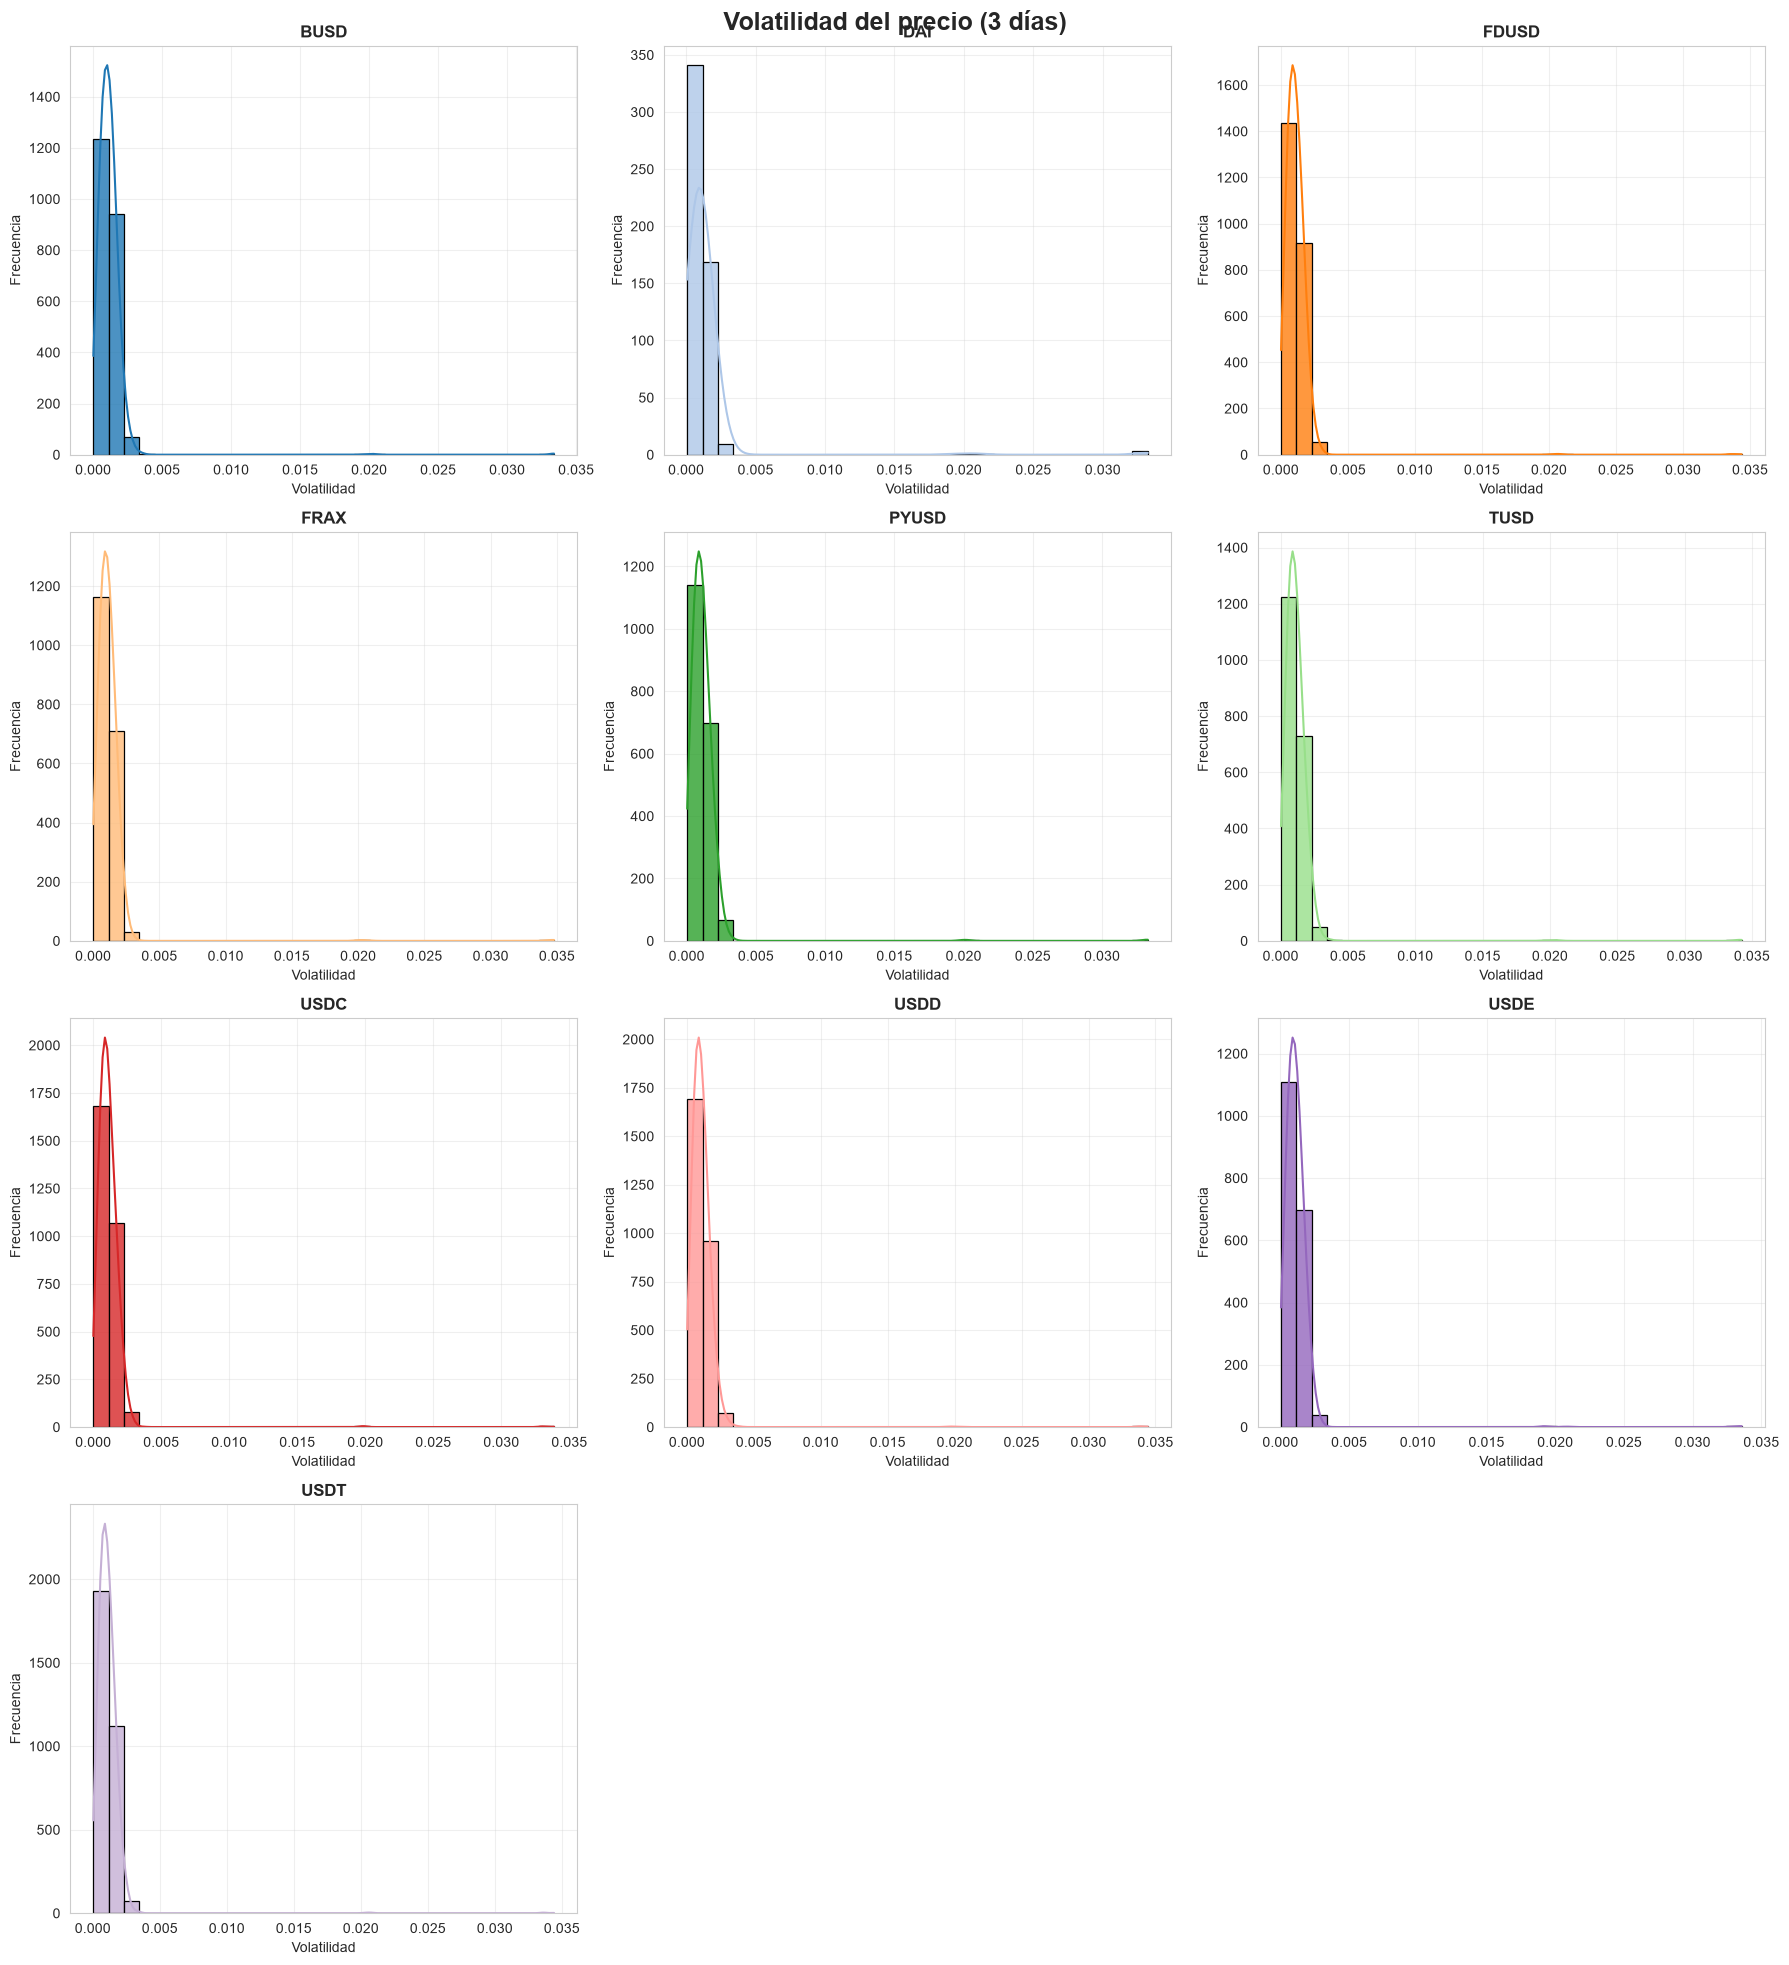

In [43]:
histograma_por_stablecoin(
    df,
    "price_volatility_3d",
    "Volatilidad del precio (3 días)",
    "Volatilidad"
)

Interpretación

La volatilidad es generalmente baja, lo cual es consistente con el objetivo principal de una stablecoin: mantener un precio estable. No obstante, algunos periodos muestran incrementos significativos de volatilidad asociados a eventos de mercado o posibles depegs.

📈 Series temporales

In [51]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

def serie_temporal_stablecoin(df, variable, titulo, ylabel):

    # Obtener todas las stablecoins
    monedas = sorted(df["stablecoin"].unique())

    # Número de columnas y filas
    ncols = 3
    nrows = math.ceil(len(monedas) / ncols)

    # Crear figura
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(20, 5 * nrows)
    )

    axes = axes.flatten()

    # Crear colores
    colores = sns.color_palette("tab20", len(monedas))

    # Crear un gráfico para cada stablecoin
    for i, moneda in enumerate(monedas):

        datos = (
            df[df["stablecoin"] == moneda]
            .sort_values("datetime")
        )

        axes[i].plot(
            datos["datetime"],
            datos[variable],
            color=colores[i],
            linewidth=2
        )

        axes[i].set_title(
            moneda,
            fontsize=12,
            fontweight="bold"
        )

        axes[i].set_xlabel("Fecha")
        axes[i].set_ylabel(ylabel)
        axes[i].grid(alpha=0.3)

    # Eliminar ejes vacíos
    for j in range(len(monedas), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(
        titulo,
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

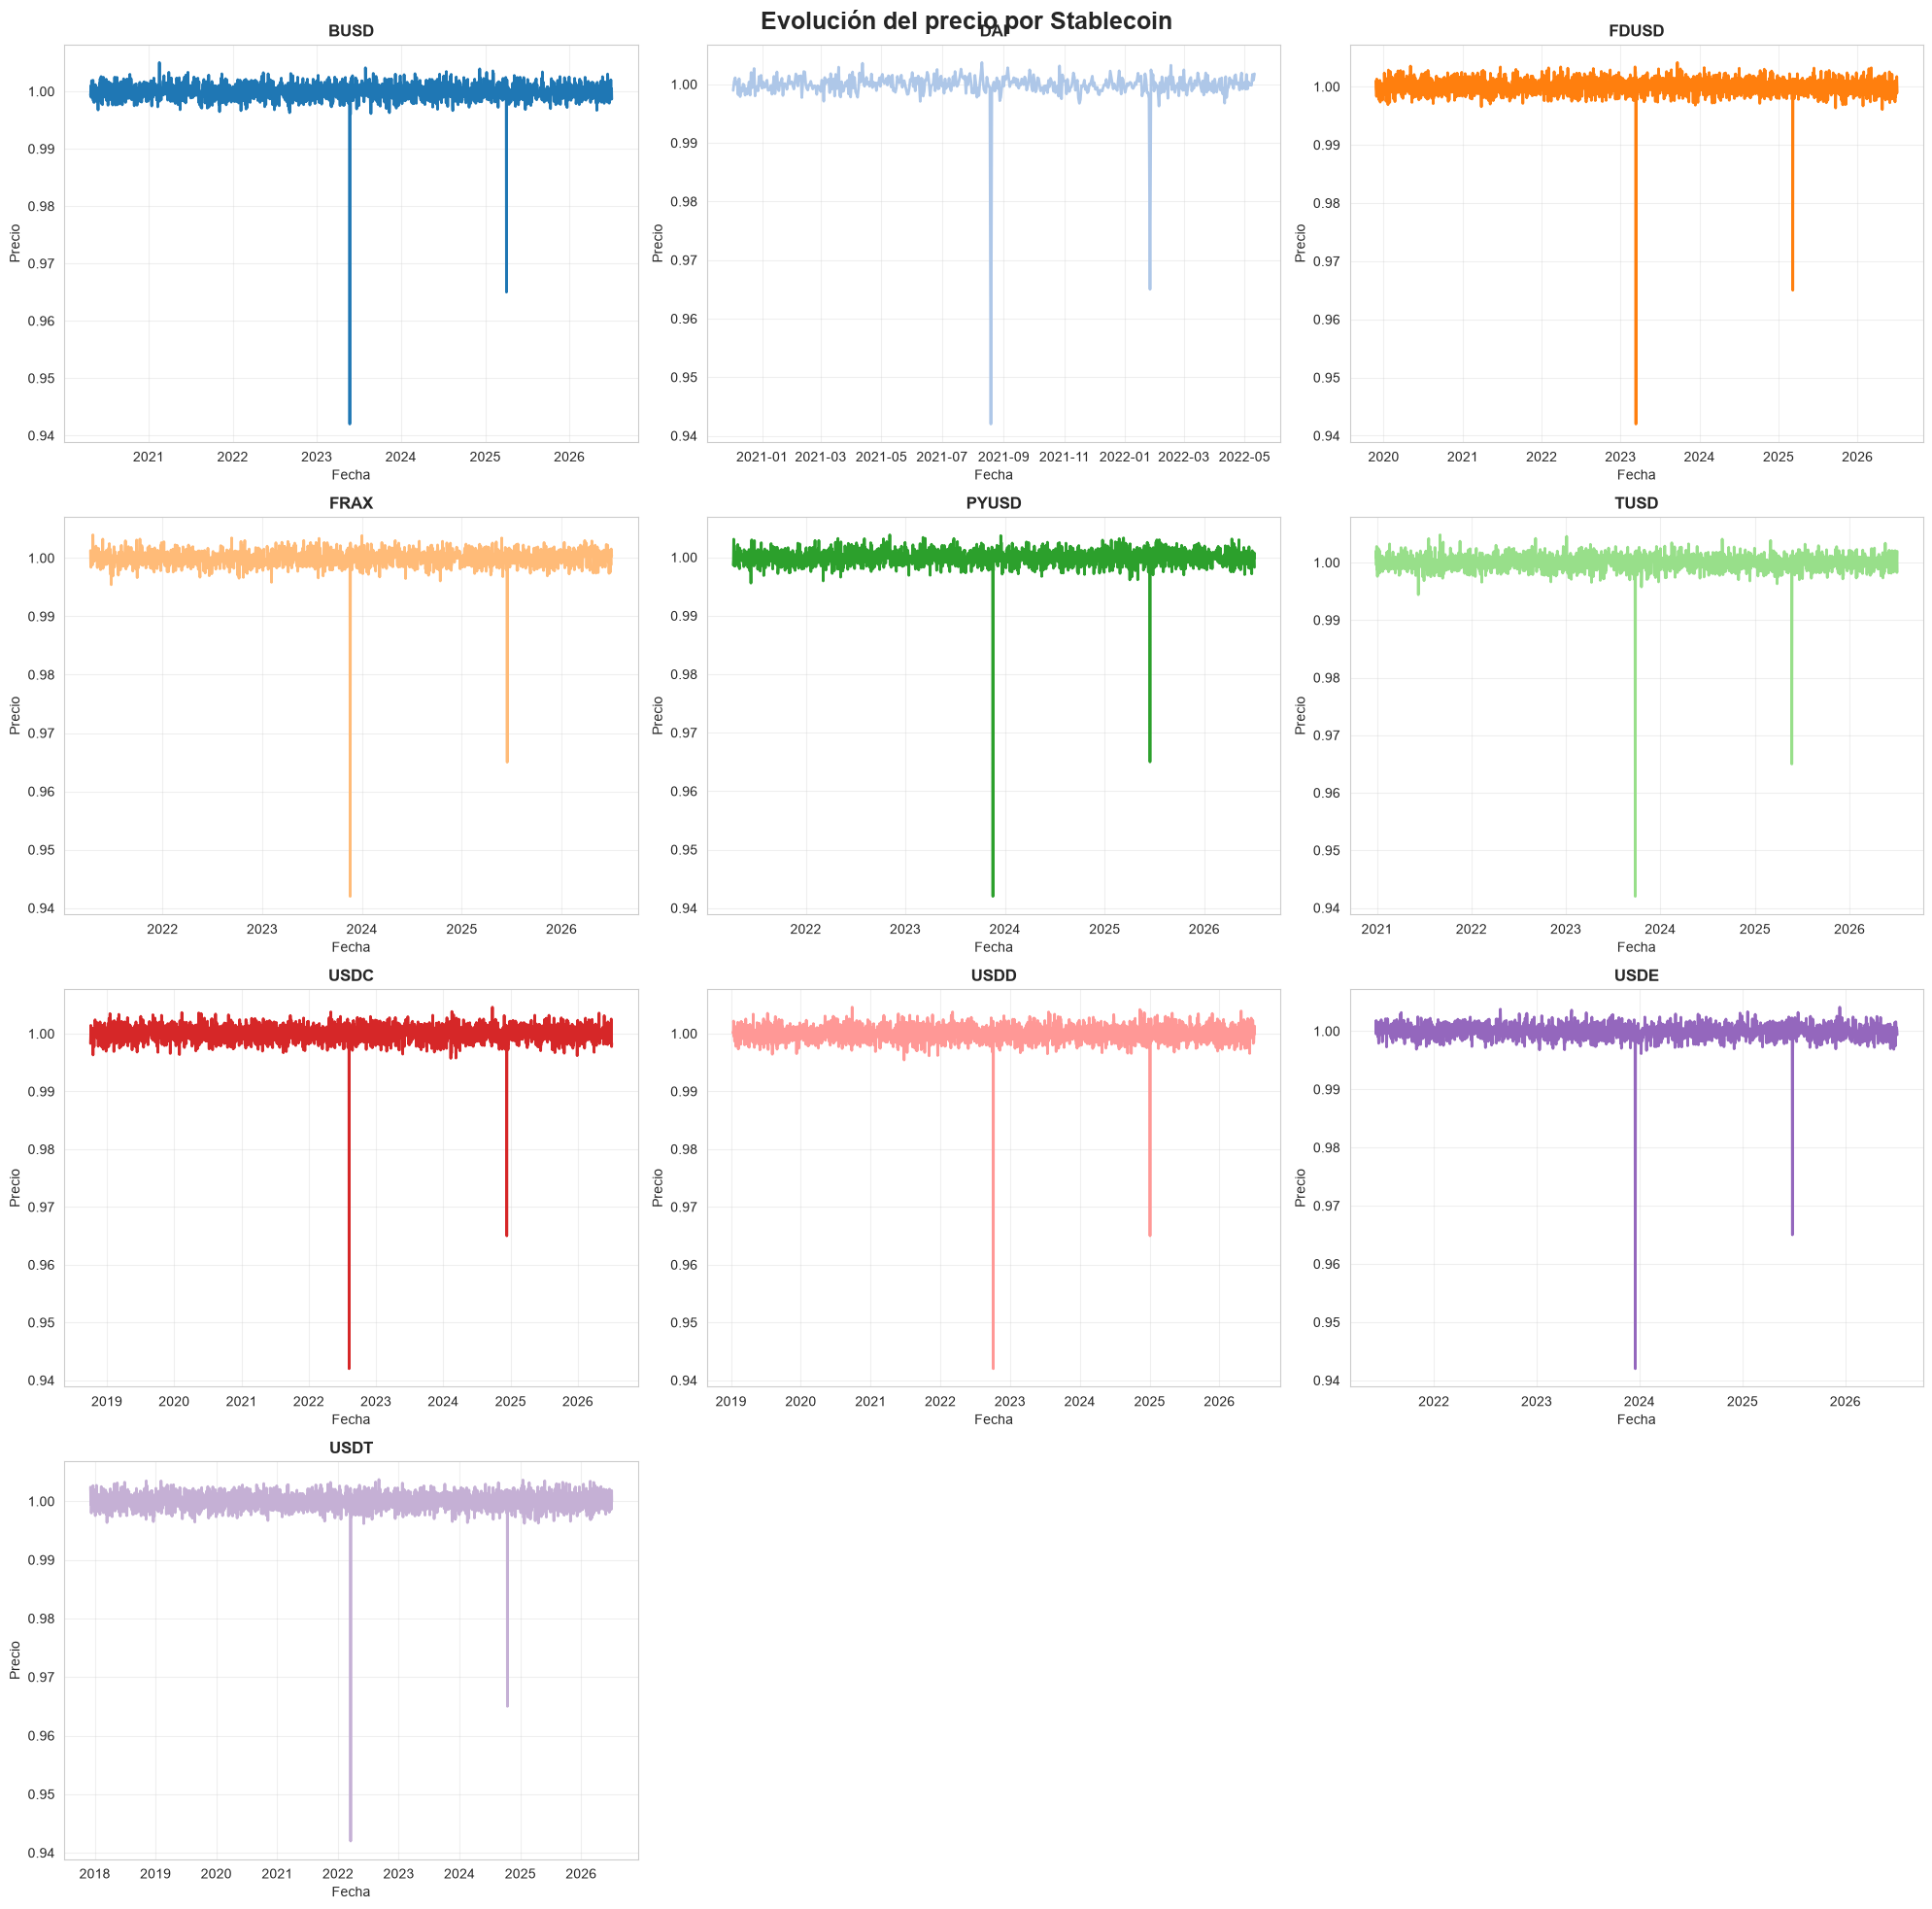

In [52]:
serie_temporal_stablecoin(
    df,
    "price",
    "Evolución del precio por Stablecoin",
    "Precio"
)

Interpretación

Las series temporales muestran que la mayoría de las stablecoins mantienen un precio cercano a su valor objetivo, con pequeñas fluctuaciones a lo largo del tiempo. Aunque se observan ligeras variaciones entre ellas, en general presentan un comportamiento estable, acorde con su función de minimizar la volatilidad.

# Conclusión del análisis univariado

El análisis univariado permitió examinar el comportamiento individual de las principales variables de las stablecoins incluidas en el conjunto de datos. En general, el precio se mantiene cercano a la paridad con el dólar estadounidense, aunque se observan pequeñas desviaciones reflejadas en la variable peg deviation. La capitalización de mercado presenta diferencias significativas entre las stablecoins, evidenciando distintos niveles de adopción y liquidez. Asimismo, las variables relacionadas con el cambio en la oferta y la volatilidad muestran que, aunque estos activos buscan mantener la estabilidad de su precio, existen periodos con variaciones asociadas a las condiciones del mercado y a cambios en la emisión o demanda de cada stablecoin.